# 주택 가격 학습 데이터 탐색적 데이터 분석(EDA)

Kaggle의 Ames 주택 가격 **학습 데이터(`data/train.csv`)만** 사용한 재현 가능한 탐색적 데이터 분석입니다. 목표 변수는 `SalePrice`이며, 평가 데이터의 샘플 수는 대회 공개 정보로만 적고 해당 파일은 읽지 않습니다.

## 핵심 요약

- **규모:** 학습 1,460개·평가 1,459개이며, 학습 데이터는 81개 열(`Id` 1개 + 예측 변수 79개 + 타깃 1개)입니다. 중복 행과 중복 `Id`는 모두 0개입니다.
- **타깃:** `SalePrice` 중앙값은 **$163,000**, 평균은 **$180,921**입니다. 왜도는 **1.883**이지만 `log1p` 변환 후 **0.121**으로 줄어듭니다.
- **전체 피처 관계:** 79개 입력 피처를 수치형 34개와 범주형 45개로 나누어 모두 확인했습니다. 수치형에서는 `OverallQual`(Spearman ρ=0.810), 범주형에서는 `Neighborhood`(상관비 η=0.756)가 가장 강한 단변량 관계를 보입니다.
- **변수 간 구조:** 수치–수치 561쌍, 범주–범주 990쌍, 범주–수치 1,530쌍을 분리해 분석했습니다. 가장 강한 수치형 중복 신호는 `GarageCars–GarageArea`(Pearson r=0.882)입니다.
- **결측 주의:** 원본의 `"NA"` 6,965개 중 6,608개는 시설 없음에 해당하는 범주형 구조적 결측이고, `GarageYrBlt`의 81개도 차고 없음과 연결됩니다. 또한 `MasVnrType="None"` 864개는 유효한 범주인데 pandas 기본 로더가 결측으로 읽을 수 있습니다.
- **이상치:** `GrLivArea > 4,000`인 4개 중 `Id=524`, `Id=1299`는 면적 대비 가격이 비정상적으로 낮아 교차검증 안정성을 따로 점검해야 합니다.
- **모델링 방향:** `log1p(SalePrice)`를 타깃으로 삼고, 의미 기반 결측 처리·희소 범주 병합·파생 변수·K-fold 검증을 파이프라인 안에서 수행하는 것이 안전합니다.

## 분석 범위와 방법

### 주요 가정

- 분석 대상은 프로젝트의 `data/train.csv` 한 파일뿐입니다.
- 평가 데이터는 대회 공개 샘플 수(1,459개)만 기록하며 실제 파일은 로드하지 않습니다.
- 분석은 기술적·예측적 관계를 다루며 인과관계를 주장하지 않습니다.
- 원본 문자열을 먼저 보존하고, `NA`가 "시설 없음"을 뜻하는 열과 실제 미상 값을 분리합니다.
- 수치형 34개는 Pearson과 순위 기반 Spearman으로, 범주형 45개는 연속 타깃에 대한 상관비(correlation ratio) `η`로 확인합니다. `MSSubClass`와 `MoSold`는 숫자로 저장됐지만 의미상 범주형으로 취급합니다.
- Pearson·Spearman의 부호는 관계 방향을 나타내지만 범주형 `η`는 0~1의 크기만 가집니다. 서로 다른 지표의 값을 직접 우열 비교하지 않습니다.
- 변수끼리는 수치–수치에 pairwise-complete Pearson·Spearman, 범주–범주에 편향 보정 Cramér's V, 범주–수치에 상관비 `η`를 사용합니다. 세 지표는 척도와 가정이 다르므로 유형별로만 순위를 해석합니다.
- 범주형 연관성은 희소 범주와 구조적 부재가 크게 만들 수 있으므로 기대빈도 5 미만 셀 비율, 최소 범주 표본 수, 희소 범주 행 비율을 함께 봅니다.

### 원본 영문 변수명 안내

Kaggle 원본 열 이름은 코드 호환성을 위해 그대로 유지합니다. 아래의 전체 컬럼 사전에서 81개 열 모두에 대해 한국어 의미, 분석용 타입, 변수 그룹, 가격 예측에 줄 수 있는 정보를 설명합니다.

In [1]:
from pathlib import Path
import warnings

import matplotlib.pyplot as plt
from matplotlib import font_manager
import numpy as np
import pandas as pd
from IPython.display import display

warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", lambda value: f"{value:,.3f}")

plt.style.use("seaborn-v0_8-whitegrid")
available_fonts = {font.name for font in font_manager.fontManager.ttflist}
korean_font = next(
    (font for font in ["Apple SD Gothic Neo", "AppleGothic", "Arial Unicode MS"] if font in available_fonts),
    "DejaVu Sans",
)
plt.rcParams.update({
    "figure.figsize": (10, 5),
    "font.family": korean_font,
    "axes.unicode_minus": False,
    "axes.titlesize": 13,
    "axes.labelsize": 10,
    "axes.edgecolor": "#334155",
    "grid.color": "#e2e8f0",
    "text.color": "#1f2937",
})

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DATA_PATH = PROJECT_ROOT / "data" / "train.csv"
print(f"사용 데이터: {DATA_PATH}")

사용 데이터: /Users/joonha/workspace/House_Prices/data/train.csv


## 데이터 이해

### 1. 학습·평가 데이터 규모와 학습 데이터 구조

In [2]:
STRUCTURAL_ABSENCE_COLUMNS = [
    "Alley", "BsmtQual", "BsmtCond", "BsmtExposure", "BsmtFinType1",
    "BsmtFinType2", "FireplaceQu", "GarageType", "GarageFinish",
    "GarageQual", "GarageCond", "PoolQC", "Fence", "MiscFeature",
]

raw = pd.read_csv(DATA_PATH, keep_default_na=False)
pandas_default = pd.read_csv(DATA_PATH)

numeric_columns = pandas_default.select_dtypes(include="number").columns.tolist()
df = raw.copy()
for column in numeric_columns:
    df[column] = pd.to_numeric(df[column].replace("NA", np.nan), errors="coerce")

for column in STRUCTURAL_ABSENCE_COLUMNS:
    df[column] = df[column].replace("NA", "None")

categorical_columns = [column for column in df.columns if column not in numeric_columns]
for column in categorical_columns:
    if column not in STRUCTURAL_ABSENCE_COLUMNS:
        df[column] = df[column].replace("NA", np.nan)

OFFICIAL_EVALUATION_ROWS = 1_459
dataset_sizes = pd.DataFrame([
    ["학습 데이터", len(df), df.shape[1], "있음", "실제 파일 로드"],
    ["평가 데이터", OFFICIAL_EVALUATION_ROWS, 80, "없음", "대회 공개 정보 — 파일 미로드"],
], columns=["구분", "샘플 수", "전체 컬럼 수", "SalePrice", "확인 방식"])
display(dataset_sizes)

overview = pd.DataFrame({
    "항목": ["행 수", "전체 열 수", "예측 변수 수", "중복 행 수", "중복 Id 수", "판매 연도 범위"],
    "값": [
        len(df), df.shape[1], df.shape[1] - 2, df.duplicated().sum(),
        df["Id"].duplicated().sum(), f"{int(df['YrSold'].min())}–{int(df['YrSold'].max())}",
    ],
})
display(overview)
sample_columns = ["Id", "SalePrice", "OverallQual", "GrLivArea", "Neighborhood", "YearBuilt", "GarageCars"]
display(
    df[sample_columns].head(5).rename(columns={
        "Id": "주택 ID",
        "SalePrice": "판매 가격",
        "OverallQual": "종합 품질",
        "GrLivArea": "지상 생활 면적",
        "Neighborhood": "동네 코드",
        "YearBuilt": "건축 연도",
        "GarageCars": "차고 수용 대수",
    })
)

,구분,샘플 수,전체 컬럼 수,SalePrice,확인 방식
0,학습 데이터,1460,81,있음,실제 파일 로드
1,평가 데이터,1459,80,없음,대회 공개 정보 — 파일 미로드


,항목,값
0,행 수,1460
1,전체 열 수,81
2,예측 변수 수,79
3,중복 행 수,0
4,중복 Id 수,0
5,판매 연도 범위,2006–2010


,주택 ID,판매 가격,종합 품질,지상 생활 면적,동네 코드,건축 연도,차고 수용 대수
0,1,208500,7,1710,CollgCr,2003,2
1,2,181500,6,1262,Veenker,1976,2
2,3,223500,7,1786,CollgCr,2001,2
3,4,140000,7,1717,Crawfor,1915,3
4,5,250000,8,2198,NoRidge,2000,3


학습 데이터는 1,460개, 평가 데이터는 1,459개로 거의 반반입니다. 학습 데이터의 81개 열은 식별자 `Id`, 79개 예측 변수, 연속형 타깃 `SalePrice`로 구성됩니다. 평가 데이터 샘플 수와 열 수는 대회 공개 정보이며 이 노트북에서는 해당 파일을 읽지 않습니다.

### 2. 전체 81개 컬럼의 의미·타입·예측 정보

In [3]:
COLUMN_CATALOG = {
    "Id": [
        "주택 식별 번호",
        "식별",
        "행을 구분하는 키이며 순번 자체는 일반화 가능한 가격 정보로 보지 않음"
    ],
    "MSSubClass": [
        "주택 유형 코드",
        "주택 유형·입지",
        "건물 형태·층수·연식 조합에 따른 가격대 차이를 포착"
    ],
    "MSZoning": [
        "일반 용도지역",
        "주택 유형·입지",
        "토지 이용 규제와 주거 환경 차이를 반영"
    ],
    "LotFrontage": [
        "도로에 접한 부지 길이(피트)",
        "부지·접근",
        "부지 규모와 접근성의 대리 변수로 활용 가능"
    ],
    "LotArea": [
        "부지 면적(제곱피트)",
        "부지·접근",
        "토지 크기와 증축·야외 공간 여력을 반영"
    ],
    "Street": [
        "도로 포장 유형",
        "부지·접근",
        "접근성 및 기반시설 수준 차이를 반영"
    ],
    "Alley": [
        "골목 접근 유형",
        "부지·접근",
        "후면 접근성과 주차·동선 편의성을 반영"
    ],
    "LotShape": [
        "부지 형태",
        "부지·접근",
        "토지 활용 효율과 건축 제약을 반영"
    ],
    "LandContour": [
        "부지 지형의 평탄도",
        "부지·접근",
        "배수·조망·시공 난이도 차이를 반영"
    ],
    "Utilities": [
        "사용 가능한 공공시설",
        "부지·접근",
        "전기·가스·상하수도 등 기반시설 수준을 반영"
    ],
    "LotConfig": [
        "부지 배치 유형",
        "부지·접근",
        "코너 여부와 도로 접면 구조에 따른 선호 차이를 반영"
    ],
    "LandSlope": [
        "부지 경사도",
        "부지·접근",
        "건축·관리 난이도와 조망 가능성을 반영"
    ],
    "Neighborhood": [
        "Ames 시내 동네",
        "주택 유형·입지",
        "학군·편의시설·지역 선호 등 위치 프리미엄을 포착"
    ],
    "Condition1": [
        "주요 도로·철도 인접 조건 1",
        "주택 유형·입지",
        "소음·접근성 같은 주변 환경 영향을 반영"
    ],
    "Condition2": [
        "주요 도로·철도 인접 조건 2",
        "주택 유형·입지",
        "두 번째 인접 환경의 추가 영향을 반영"
    ],
    "BldgType": [
        "주거 건물 유형",
        "주택 유형·입지",
        "단독·타운하우스 등 소유·밀도 구조에 따른 가격 차이를 포착"
    ],
    "HouseStyle": [
        "주택 층수와 스타일",
        "구조·연식",
        "층 구성과 생활 동선에 대한 선호를 반영"
    ],
    "OverallQual": [
        "전체 자재·마감 품질 등급",
        "품질·상태",
        "주택 전반의 품질을 요약하는 핵심 가격 신호"
    ],
    "OverallCond": [
        "전체 현재 상태 등급",
        "품질·상태",
        "유지보수 상태와 향후 수리 비용을 반영"
    ],
    "YearBuilt": [
        "최초 건축 연도",
        "구조·연식",
        "주택 연령·건축 기준·설계 세대 차이를 반영"
    ],
    "YearRemodAdd": [
        "리모델링 연도",
        "구조·연식",
        "개보수의 최신성과 내부 상태 개선 정도를 반영"
    ],
    "RoofStyle": [
        "지붕 형태",
        "외장·구조",
        "설계 선호와 유지관리 특성을 반영"
    ],
    "RoofMatl": [
        "지붕 재료",
        "외장·구조",
        "내구성·교체 비용·희소한 고급 자재 효과를 반영"
    ],
    "Exterior1st": [
        "주 외벽 재료",
        "외장·구조",
        "외관 품질·내구성·관리 비용을 반영"
    ],
    "Exterior2nd": [
        "보조 외벽 재료",
        "외장·구조",
        "혼합 외장 구성과 추가 마감 정보를 제공"
    ],
    "MasVnrType": [
        "석재 베니어 유형",
        "외장·구조",
        "외관 고급화 여부와 마감 수준을 반영"
    ],
    "MasVnrArea": [
        "석재 베니어 면적(제곱피트)",
        "외장·구조",
        "고급 외장 마감의 규모를 수치로 반영"
    ],
    "ExterQual": [
        "외장 재료 품질",
        "품질·상태",
        "외관 자재의 등급과 교체 비용을 반영"
    ],
    "ExterCond": [
        "외장 현재 상태",
        "품질·상태",
        "외부 유지보수 상태와 수리 필요성을 반영"
    ],
    "Foundation": [
        "기초 유형",
        "외장·구조",
        "건축 방식·연식·지하 공간 특성을 반영"
    ],
    "BsmtQual": [
        "지하층 높이·품질",
        "지하층",
        "지하 공간의 활용 가능성과 품질을 반영"
    ],
    "BsmtCond": [
        "지하층 상태",
        "지하층",
        "습기·구조 상태와 수리 위험을 반영"
    ],
    "BsmtExposure": [
        "지하층 외부 노출 정도",
        "지하층",
        "채광과 워크아웃 출입 가능성에 따른 효용을 반영"
    ],
    "BsmtFinType1": [
        "주 지하층 마감 품질",
        "지하층",
        "완성된 생활 공간의 용도와 마감 수준을 반영"
    ],
    "BsmtFinSF1": [
        "주 지하층 마감 면적",
        "지하층",
        "실제로 활용 가능한 마감 지하층 규모를 반영"
    ],
    "BsmtFinType2": [
        "보조 지하층 마감 품질",
        "지하층",
        "두 번째 마감 공간의 추가 품질 정보를 제공"
    ],
    "BsmtFinSF2": [
        "보조 지하층 마감 면적",
        "지하층",
        "추가 마감 지하층의 규모를 반영"
    ],
    "BsmtUnfSF": [
        "미마감 지하층 면적",
        "지하층",
        "저장 공간과 향후 확장 가능성을 반영"
    ],
    "TotalBsmtSF": [
        "전체 지하층 면적",
        "지하층",
        "지하층 전체 규모를 나타내는 핵심 면적 신호"
    ],
    "Heating": [
        "난방 방식",
        "설비",
        "설비 유형별 효율·보편성·교체 비용을 반영"
    ],
    "HeatingQC": [
        "난방 품질과 상태",
        "설비",
        "난방 효율과 설비 상태에 따른 선호를 반영"
    ],
    "CentralAir": [
        "중앙 냉방 여부",
        "설비",
        "냉방 편의성과 현대화 수준을 반영"
    ],
    "Electrical": [
        "전기 시스템 유형",
        "설비",
        "전기 설비의 현대성·안전성·교체 필요성을 반영"
    ],
    "1stFlrSF": [
        "1층 면적(제곱피트)",
        "실내 공간",
        "주 생활층의 크기와 동선 편의성을 반영"
    ],
    "2ndFlrSF": [
        "2층 면적(제곱피트)",
        "실내 공간",
        "추가 생활 공간과 층 구성 정보를 제공"
    ],
    "LowQualFinSF": [
        "저품질 마감 면적",
        "실내 공간",
        "전체 면적 중 활용 가치가 낮은 부분을 구분"
    ],
    "GrLivArea": [
        "지상 생활 면적(제곱피트)",
        "실내 공간",
        "실제 거주 가능한 지상 면적으로 가격의 핵심 규모 신호"
    ],
    "BsmtFullBath": [
        "지하층 전체 욕실 수",
        "실내 공간",
        "지하층 생활 편의성과 완성도를 반영"
    ],
    "BsmtHalfBath": [
        "지하층 반욕실 수",
        "실내 공간",
        "지하 공간의 추가 편의시설을 반영"
    ],
    "FullBath": [
        "지상 전체 욕실 수",
        "실내 공간",
        "가구 규모 대응력과 생활 편의성을 반영"
    ],
    "HalfBath": [
        "지상 반욕실 수",
        "실내 공간",
        "공용 공간의 추가 편의성을 반영"
    ],
    "BedroomAbvGr": [
        "지상 침실 수",
        "실내 공간",
        "수용 가능한 가구 규모와 방 구성을 반영"
    ],
    "KitchenAbvGr": [
        "지상 주방 수",
        "실내 공간",
        "주택 구조와 다가구 가능성·공간 배분을 반영"
    ],
    "KitchenQual": [
        "주방 품질",
        "품질·상태",
        "구매자가 중시하는 주방 마감과 리모델링 비용을 반영"
    ],
    "TotRmsAbvGrd": [
        "지상 전체 방 수",
        "실내 공간",
        "욕실을 제외한 공간 구성과 주택 규모를 반영"
    ],
    "Functional": [
        "주택 기능성 등급",
        "품질·상태",
        "구조적 결함과 정상 사용 가능성을 반영"
    ],
    "Fireplaces": [
        "벽난로 수",
        "실내 공간",
        "부가 편의시설과 고급 주택 특성을 반영"
    ],
    "FireplaceQu": [
        "벽난로 품질",
        "품질·상태",
        "벽난로의 존재뿐 아니라 실제 마감 수준을 반영"
    ],
    "GarageType": [
        "차고 위치 유형",
        "차고",
        "주택 연결성·접근 편의와 건축 구성을 반영"
    ],
    "GarageYrBlt": [
        "차고 건축 연도",
        "차고",
        "차고의 연령과 본채와의 일치·개량 여부를 반영"
    ],
    "GarageFinish": [
        "차고 내부 마감",
        "차고",
        "차고의 완성도와 활용 수준을 반영"
    ],
    "GarageCars": [
        "차고 수용 차량 수",
        "차고",
        "주차 용량을 나타내는 강한 편의·규모 신호"
    ],
    "GarageArea": [
        "차고 면적(제곱피트)",
        "차고",
        "차고의 실제 크기와 저장 여력을 반영"
    ],
    "GarageQual": [
        "차고 품질",
        "차고",
        "차고 자재와 시공 품질을 반영"
    ],
    "GarageCond": [
        "차고 상태",
        "차고",
        "차고 유지보수 상태와 수리 비용을 반영"
    ],
    "PavedDrive": [
        "진입로 포장 상태",
        "부지·접근",
        "차량 접근성과 외부 마감 완성도를 반영"
    ],
    "WoodDeckSF": [
        "목재 데크 면적",
        "야외 공간",
        "휴식·활동 가능한 야외 공간의 규모를 반영"
    ],
    "OpenPorchSF": [
        "개방형 현관 면적",
        "야외 공간",
        "현관의 활용도와 외관 매력을 반영"
    ],
    "EnclosedPorch": [
        "폐쇄형 현관 면적",
        "야외 공간",
        "보호된 추가 공간의 크기를 반영"
    ],
    "3SsnPorch": [
        "3계절용 현관 면적",
        "야외 공간",
        "계절성 여가 공간의 존재와 규모를 반영"
    ],
    "ScreenPorch": [
        "스크린 현관 면적",
        "야외 공간",
        "방충형 야외 생활 공간의 규모를 반영"
    ],
    "PoolArea": [
        "수영장 면적",
        "야외 공간",
        "희소한 고급 편의시설의 존재와 규모를 반영"
    ],
    "PoolQC": [
        "수영장 품질",
        "야외 공간",
        "수영장의 상태와 고급화 수준을 반영"
    ],
    "Fence": [
        "울타리 품질",
        "야외 공간",
        "사생활 보호와 외부 시설 상태를 반영"
    ],
    "MiscFeature": [
        "기타 부가 시설",
        "야외 공간",
        "엘리베이터·테니스장 등 드문 추가 시설을 표시"
    ],
    "MiscVal": [
        "기타 부가 시설 가치",
        "야외 공간",
        "드문 시설의 추정 금전 가치를 반영"
    ],
    "MoSold": [
        "판매 월",
        "거래",
        "계절별 거래 수요와 가격 패턴을 반영"
    ],
    "YrSold": [
        "판매 연도",
        "거래",
        "2006~2010년 시장 수준과 시간 효과를 반영"
    ],
    "SaleType": [
        "판매 방식",
        "거래",
        "일반·신축·계약 방식에 따른 가격 형성 차이를 반영"
    ],
    "SaleCondition": [
        "판매 조건",
        "거래",
        "정상·가족·급매 등 거래 상황에 따른 가격 차이를 반영"
    ],
    "SalePrice": [
        "판매 가격(달러)",
        "타깃",
        "모델이 예측해야 하는 연속형 정답 변수"
    ]
}

def analytical_type(column):
    if column == "Id":
        return "식별자"
    if column == "SalePrice":
        return "타깃(연속형)"
    if column == "MSSubClass":
        return "범주형(숫자 코드)"
    if column in ("OverallQual", "OverallCond"):
        return "순서형(숫자 등급)"
    if column == "MoSold":
        return "주기형(숫자 월)"
    if column == "YrSold":
        return "시간형(숫자 연도)"
    if pd.api.types.is_numeric_dtype(df[column]):
        return "수치형"
    return "범주형(문자열)"

catalog_missing = [column for column in df.columns if column not in COLUMN_CATALOG]
assert not catalog_missing, f"컬럼 설명 누락: {catalog_missing}"

schema_rows = []
for column in df.columns:
    meaning, group, predictive_information = COLUMN_CATALOG[column]
    schema_rows.append({
        "컬럼": column,
        "한국어 의미": meaning,
        "pandas dtype": str(df[column].dtype),
        "분석용 타입": analytical_type(column),
        "변수 그룹": group,
        "고유값 수": int(df[column].nunique(dropna=True)),
        "NA 토큰 수": int(raw[column].eq("NA").sum()),
        "가격 예측에 제공할 수 있는 정보": predictive_information,
    })

schema_table = pd.DataFrame(schema_rows)
type_summary = (
    schema_table["분석용 타입"].value_counts().rename_axis("분석용 타입").to_frame("컬럼 수")
)
display(type_summary)
with pd.option_context("display.max_rows", None, "display.max_colwidth", 80):
    display(schema_table)

FEATURE_KO = {
    column: values[0] for column, values in COLUMN_CATALOG.items()
}


,컬럼 수
분석용 타입,
범주형(문자열),43
수치형,31
순서형(숫자 등급),2
식별자,1
범주형(숫자 코드),1
주기형(숫자 월),1
시간형(숫자 연도),1
타깃(연속형),1


,컬럼,한국어 의미,pandas dtype,분석용 타입,변수 그룹,고유값 수,NA 토큰 수,가격 예측에 제공할 수 있는 정보
0,Id,주택 식별 번호,int64,식별자,식별,1460,0,행을 구분하는 키이며 순번 자체는 일반화 가능한 가격 정보로 보지 않음
1,MSSubClass,주택 유형 코드,int64,범주형(숫자 코드),주택 유형·입지,15,0,건물 형태·층수·연식 조합에 따른 가격대 차이를 포착
2,MSZoning,일반 용도지역,object,범주형(문자열),주택 유형·입지,5,0,토지 이용 규제와 주거 환경 차이를 반영
3,LotFrontage,도로에 접한 부지 길이(피트),float64,수치형,부지·접근,110,259,부지 규모와 접근성의 대리 변수로 활용 가능
4,LotArea,부지 면적(제곱피트),int64,수치형,부지·접근,1073,0,토지 크기와 증축·야외 공간 여력을 반영
5,Street,도로 포장 유형,object,범주형(문자열),부지·접근,2,0,접근성 및 기반시설 수준 차이를 반영
6,Alley,골목 접근 유형,object,범주형(문자열),부지·접근,3,1369,후면 접근성과 주차·동선 편의성을 반영
7,LotShape,부지 형태,object,범주형(문자열),부지·접근,4,0,토지 활용 효율과 건축 제약을 반영
8,LandContour,부지 지형의 평탄도,object,범주형(문자열),부지·접근,4,0,배수·조망·시공 난이도 차이를 반영
9,Utilities,사용 가능한 공공시설,object,범주형(문자열),부지·접근,2,0,전기·가스·상하수도 등 기반시설 수준을 반영


`pandas dtype`와 모델링 관점의 타입은 다를 수 있습니다. 예를 들어 `MSSubClass`는 숫자로 저장됐지만 크기를 계산하는 연속값이 아니라 주택 유형을 나타내는 범주 코드입니다. `OverallQual`·`OverallCond`는 순서가 있는 등급이고, `MoSold`는 12월 다음에 1월이 오는 주기형 변수입니다. 이런 의미를 무시하고 모든 숫자 열을 같은 방식으로 처리하면 모델이 잘못된 거리 관계를 학습할 수 있습니다.

## 데이터 품질 점검

### 3. 시설 없음과 실제 미상 값 구분하기

,NA 개수,전체 행 대비 비율,의미
수영장 품질,1453,0.995,해당 시설 없음
기타 부가 시설,1406,0.963,해당 시설 없음
골목 접근 유형,1369,0.938,해당 시설 없음
울타리 품질,1179,0.808,해당 시설 없음
벽난로 품질,690,0.473,해당 시설 없음
도로에 접한 부지 길이(피트),259,0.177,실제 미상 값 — 대치 필요
차고 건축 연도,81,0.055,차고 없음
차고 상태,81,0.055,해당 시설 없음
차고 위치 유형,81,0.055,해당 시설 없음
차고 내부 마감,81,0.055,해당 시설 없음


문자열 NA 전체 개수: 6,965
시설 없음에 해당하는 범주형 NA: 6,608
차고 없음에 해당하는 차고 연도 NA: 81
그 밖의 실제 미상 값: 276
원본의 MasVnrType='None' 개수: 864
pandas 기본 설정에서 MasVnrType 결측 개수: 872


,품질 점검 항목,개수,해석·처리 원칙
0,문자열 NA 토큰,6965,시설 없음과 실제 미상을 분리해 처리
1,실제 미상 값,276,학습 fold 내부에서 대치
2,완전히 같은 중복 행,0,없음
3,중복 Id,0,Id는 학습 행의 고유 키
4,SalePrice 결측,0,타깃 결측 없음
5,0 이하 SalePrice,0,로그 변환을 막는 값 없음
6,"GrLivArea > 4,000",4,대형 주택 이상치 후보 — 자동 삭제 금지


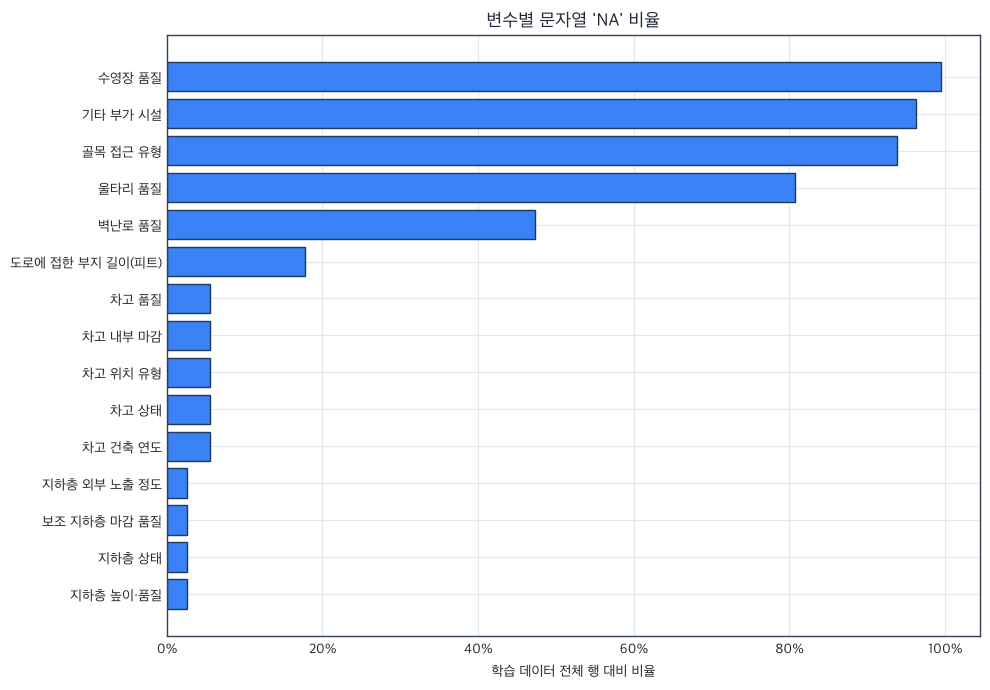

In [4]:
literal_na = raw.eq("NA").sum().sort_values(ascending=False)
missing_tokens = literal_na[literal_na > 0].rename("count").to_frame()
missing_tokens["rate"] = missing_tokens["count"] / len(raw)
missing_tokens["meaning"] = [
    "해당 시설 없음" if feature in STRUCTURAL_ABSENCE_COLUMNS
    else "차고 없음" if feature == "GarageYrBlt"
    else "실제 미상 값 — 대치 필요"
    for feature in missing_tokens.index
]

structural_count = int(raw[STRUCTURAL_ABSENCE_COLUMNS].eq("NA").sum().sum())
garage_year_count = int(raw["GarageYrBlt"].eq("NA").sum())
unknown_count = int(raw.eq("NA").sum().sum()) - structural_count - garage_year_count

display(
    missing_tokens.rename(index=FEATURE_KO).rename(
        columns={"count": "NA 개수", "rate": "전체 행 대비 비율", "meaning": "의미"}
    )
)
print(f"문자열 NA 전체 개수: {int(raw.eq('NA').sum().sum()):,}")
print(f"시설 없음에 해당하는 범주형 NA: {structural_count:,}")
print(f"차고 없음에 해당하는 차고 연도 NA: {garage_year_count:,}")
print(f"그 밖의 실제 미상 값: {unknown_count:,}")
print(f"원본의 MasVnrType='None' 개수: {(raw['MasVnrType'] == 'None').sum():,}")
print(f"pandas 기본 설정에서 MasVnrType 결측 개수: {pandas_default['MasVnrType'].isna().sum():,}")

quality_status = pd.DataFrame([
    ["문자열 NA 토큰", int(raw.eq("NA").sum().sum()), "시설 없음과 실제 미상을 분리해 처리"],
    ["실제 미상 값", unknown_count, "학습 fold 내부에서 대치"],
    ["완전히 같은 중복 행", int(df.duplicated().sum()), "없음"],
    ["중복 Id", int(df["Id"].duplicated().sum()), "Id는 학습 행의 고유 키"],
    ["SalePrice 결측", int(df["SalePrice"].isna().sum()), "타깃 결측 없음"],
    ["0 이하 SalePrice", int((df["SalePrice"] <= 0).sum()), "로그 변환을 막는 값 없음"],
    ["GrLivArea > 4,000", int((df["GrLivArea"] > 4000).sum()), "대형 주택 이상치 후보 — 자동 삭제 금지"],
], columns=["품질 점검 항목", "개수", "해석·처리 원칙"])
display(quality_status)

plot_data = missing_tokens.head(15).sort_values("rate")
plot_data.index = [FEATURE_KO.get(feature, feature) for feature in plot_data.index]
fig, ax = plt.subplots(figsize=(10, 7))
ax.barh(plot_data.index, plot_data["rate"], color="#3b82f6", edgecolor="#1e3a5f")
ax.set_title("변수별 문자열 'NA' 비율")
ax.set_xlabel("학습 데이터 전체 행 대비 비율")
ax.set_ylabel("")
ax.xaxis.set_major_formatter(lambda value, _: f"{value:.0%}")
plt.tight_layout()
plt.show()

`dropna()`를 적용하면 구조적으로 존재하지 않는 시설까지 결측으로 취급하게 됩니다. 특히 현재 pandas 기본 설정은 `MasVnrType="None"`도 결측으로 읽어 8개의 실제 `NA`와 합쳐 872개의 null을 만들 수 있으므로, 위처럼 원본 토큰을 보존한 뒤 의미를 부여해야 합니다.

## 주요 결과

### 4. 타깃 분포와 클래스 불균형 해당 여부

,값
최솟값,"34,900.000"
제1사분위수,"129,975.000"
중앙값,"163,000.000"
평균,"180,921.196"
제3사분위수,"214,000.000"
최댓값,"755,000.000"
표준편차,"79,442.503"
원가격 왜도,1.883
로그 변환 후 왜도,0.121
IQR 상단 경계,"340,037.500"


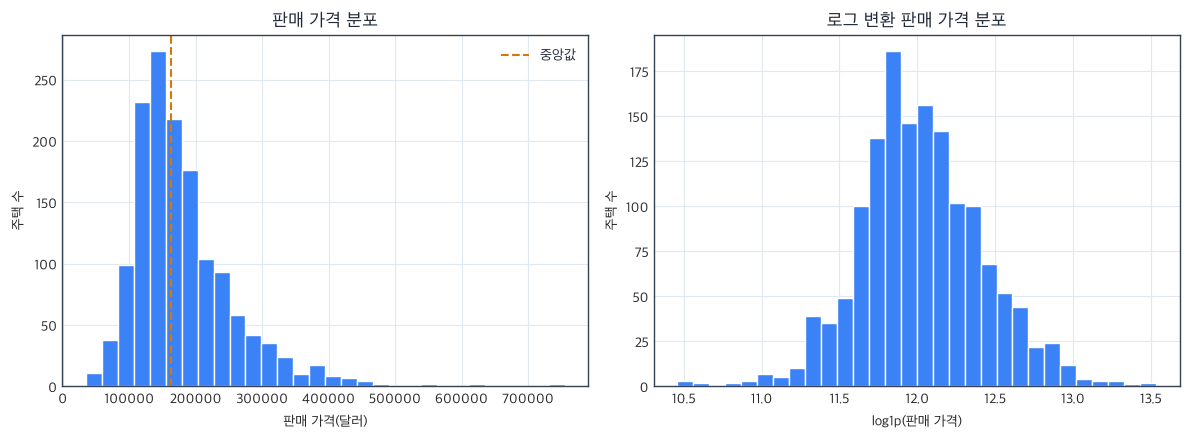

In [5]:
target = df["SalePrice"]
log_target = np.log1p(target)
target_q1 = target.quantile(0.25)
target_q3 = target.quantile(0.75)
target_iqr_upper = target_q3 + 1.5 * (target_q3 - target_q1)
target_iqr_upper_count = int((target > target_iqr_upper).sum())

target_summary = pd.Series({
    "최솟값": target.min(),
    "제1사분위수": target.quantile(0.25),
    "중앙값": target.median(),
    "평균": target.mean(),
    "제3사분위수": target.quantile(0.75),
    "최댓값": target.max(),
    "표준편차": target.std(),
    "원가격 왜도": target.skew(),
    "로그 변환 후 왜도": log_target.skew(),
    "IQR 상단 경계": target_iqr_upper,
    "IQR 상단 이상치 개수": target_iqr_upper_count,
    "IQR 상단 이상치 비율": target_iqr_upper_count / len(target),
})
display(target_summary.to_frame("값"))

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].hist(target, bins=30, color="#3b82f6", edgecolor="white")
axes[0].axvline(target.median(), color="#d97706", linestyle="--", label="중앙값")
axes[0].set_title("판매 가격 분포")
axes[0].set_xlabel("판매 가격(달러)")
axes[0].set_ylabel("주택 수")
axes[0].legend(frameon=False)

axes[1].hist(log_target, bins=30, color="#3b82f6", edgecolor="white")
axes[1].set_title("로그 변환 판매 가격 분포")
axes[1].set_xlabel("log1p(판매 가격)")
axes[1].set_ylabel("주택 수")

plt.tight_layout()
plt.show()

이 문제는 범주를 맞히는 분류가 아니라 연속적인 집값을 예측하는 **회귀 문제**이므로, 클래스 불균형은 해당되지 않습니다. 대신 비싼 주택이 소수인 **타깃 분포의 오른쪽 꼬리**를 확인해야 합니다. 원가격은 평균이 중앙값보다 약 11% 높고, IQR 상단 경계 $340,038를 넘는 주택은 61개(4.2%)입니다. `log1p(SalePrice)` 변환은 왜도를 1.883에서 0.121으로 줄여 로그 기반 평가와 모델 학습을 더 안정적으로 만듭니다.

### 5. 79개 전체 피처와 판매 가격의 단변량 관계

,피처 유형,피처 수,관계 지표,해석
0,수치형,34,Pearson·Spearman,방향과 선형·단조 관계
1,범주형,45,상관비 η,범주별 로그 가격 평균의 분리 정도
2,합계,79,피처 79개 전체,Id와 SalePrice만 제외


,한국어 의미,원가격 Pearson r,로그가격 Pearson r,로그가격 Spearman ρ,|Spearman ρ|,유효 표본 수,결측 수
원본 변수,,,,,,,
OverallQual,전체 자재·마감 품질 등급,0.791,0.817,0.810,0.810,1460,0
GrLivArea,지상 생활 면적(제곱피트),0.709,0.701,0.731,0.731,1460,0
GarageCars,차고 수용 차량 수,0.640,0.681,0.691,0.691,1460,0
YearBuilt,최초 건축 연도,0.523,0.587,0.653,0.653,1460,0
GarageArea,차고 면적(제곱피트),0.623,0.651,0.649,0.649,1460,0
FullBath,지상 전체 욕실 수,0.561,0.595,0.636,0.636,1460,0
TotalBsmtSF,전체 지하층 면적,0.614,0.612,0.603,0.603,1460,0
GarageYrBlt,차고 건축 연도,0.486,0.541,0.593,0.593,1379,81
1stFlrSF,1층 면적(제곱피트),0.606,0.597,0.575,0.575,1460,0


,한국어 의미,원가격 η,로그가격 η,범주 수,최소 범주 표본 수,표본 10개 미만 범주 수,희소 범주 행 비율
원본 변수,,,,,,,
Neighborhood,Ames 시내 동네,0.739,0.756,25,2,2,0.008
ExterQual,외장 재료 품질,0.691,0.679,4,14,0,0.000
BsmtQual,지하층 높이·품질,0.682,0.673,5,35,0,0.000
KitchenQual,주방 품질,0.676,0.669,4,39,0,0.000
GarageFinish,차고 내부 마감,0.553,0.617,4,81,0,0.000
GarageType,차고 위치 유형,0.499,0.578,7,6,2,0.010
MSSubClass,주택 유형 코드,0.496,0.575,15,4,1,0.003
FireplaceQu,벽난로 품질,0.542,0.558,6,20,0,0.000
Foundation,기초 유형,0.506,0.551,6,3,2,0.006


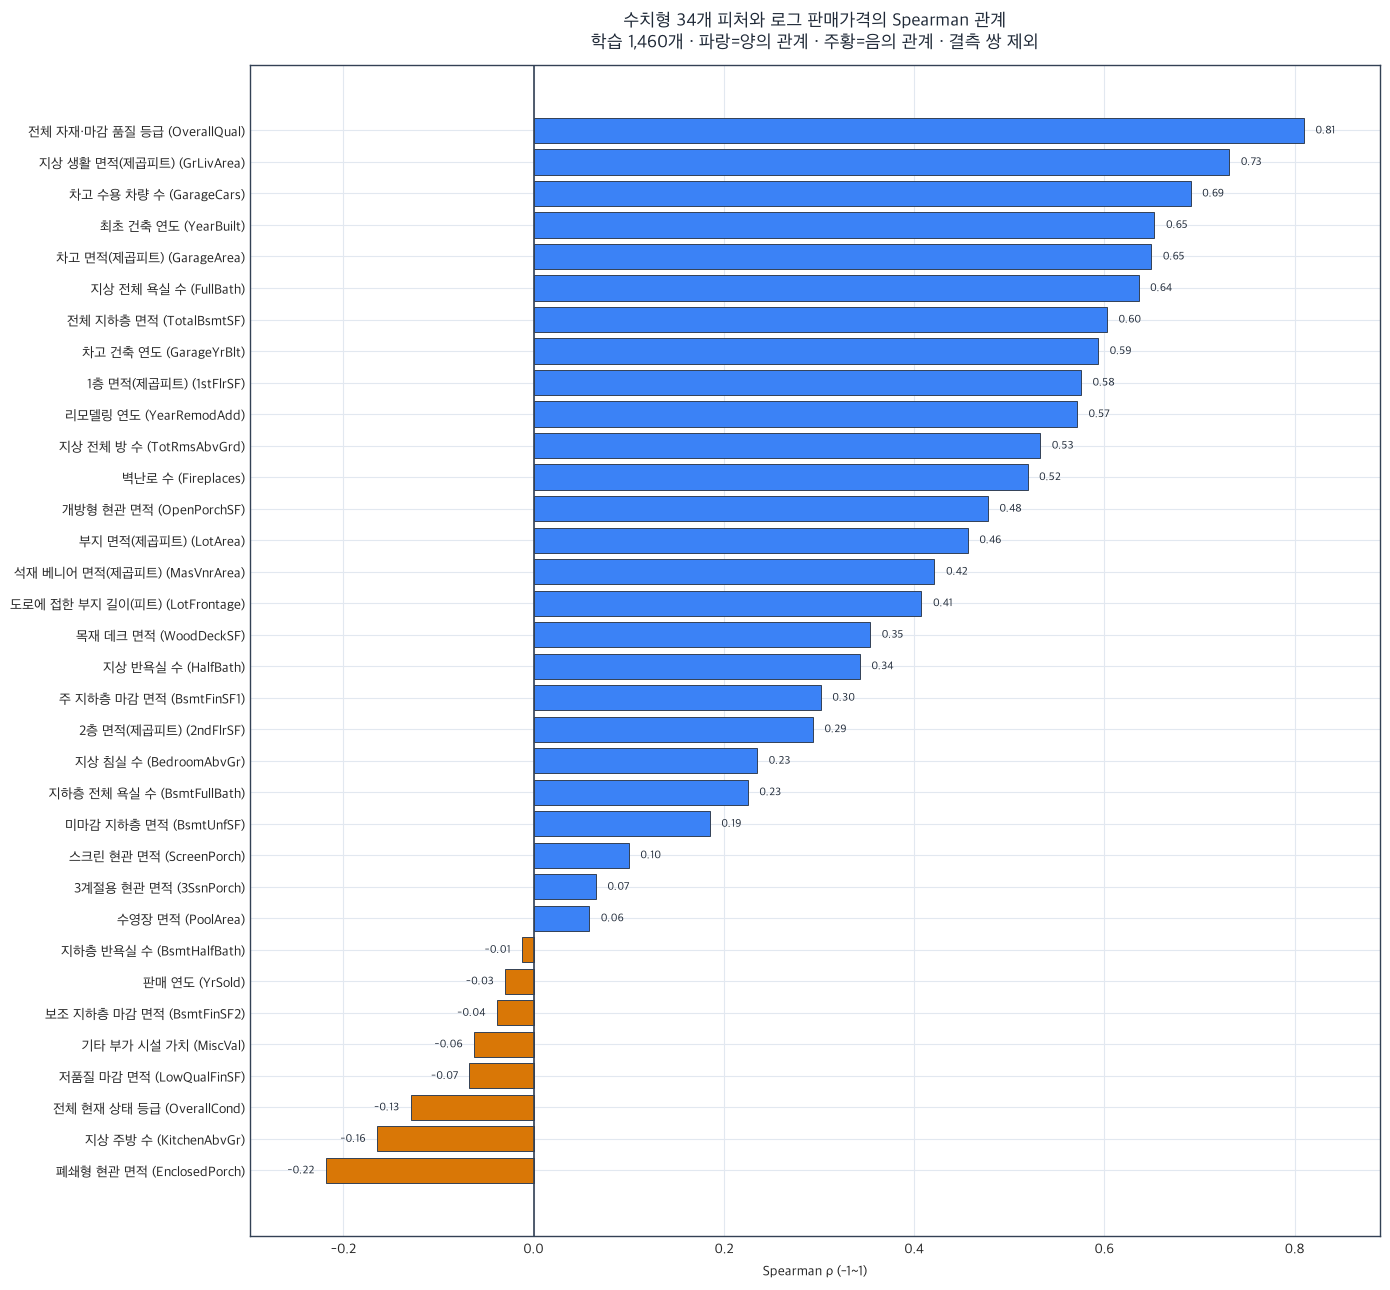

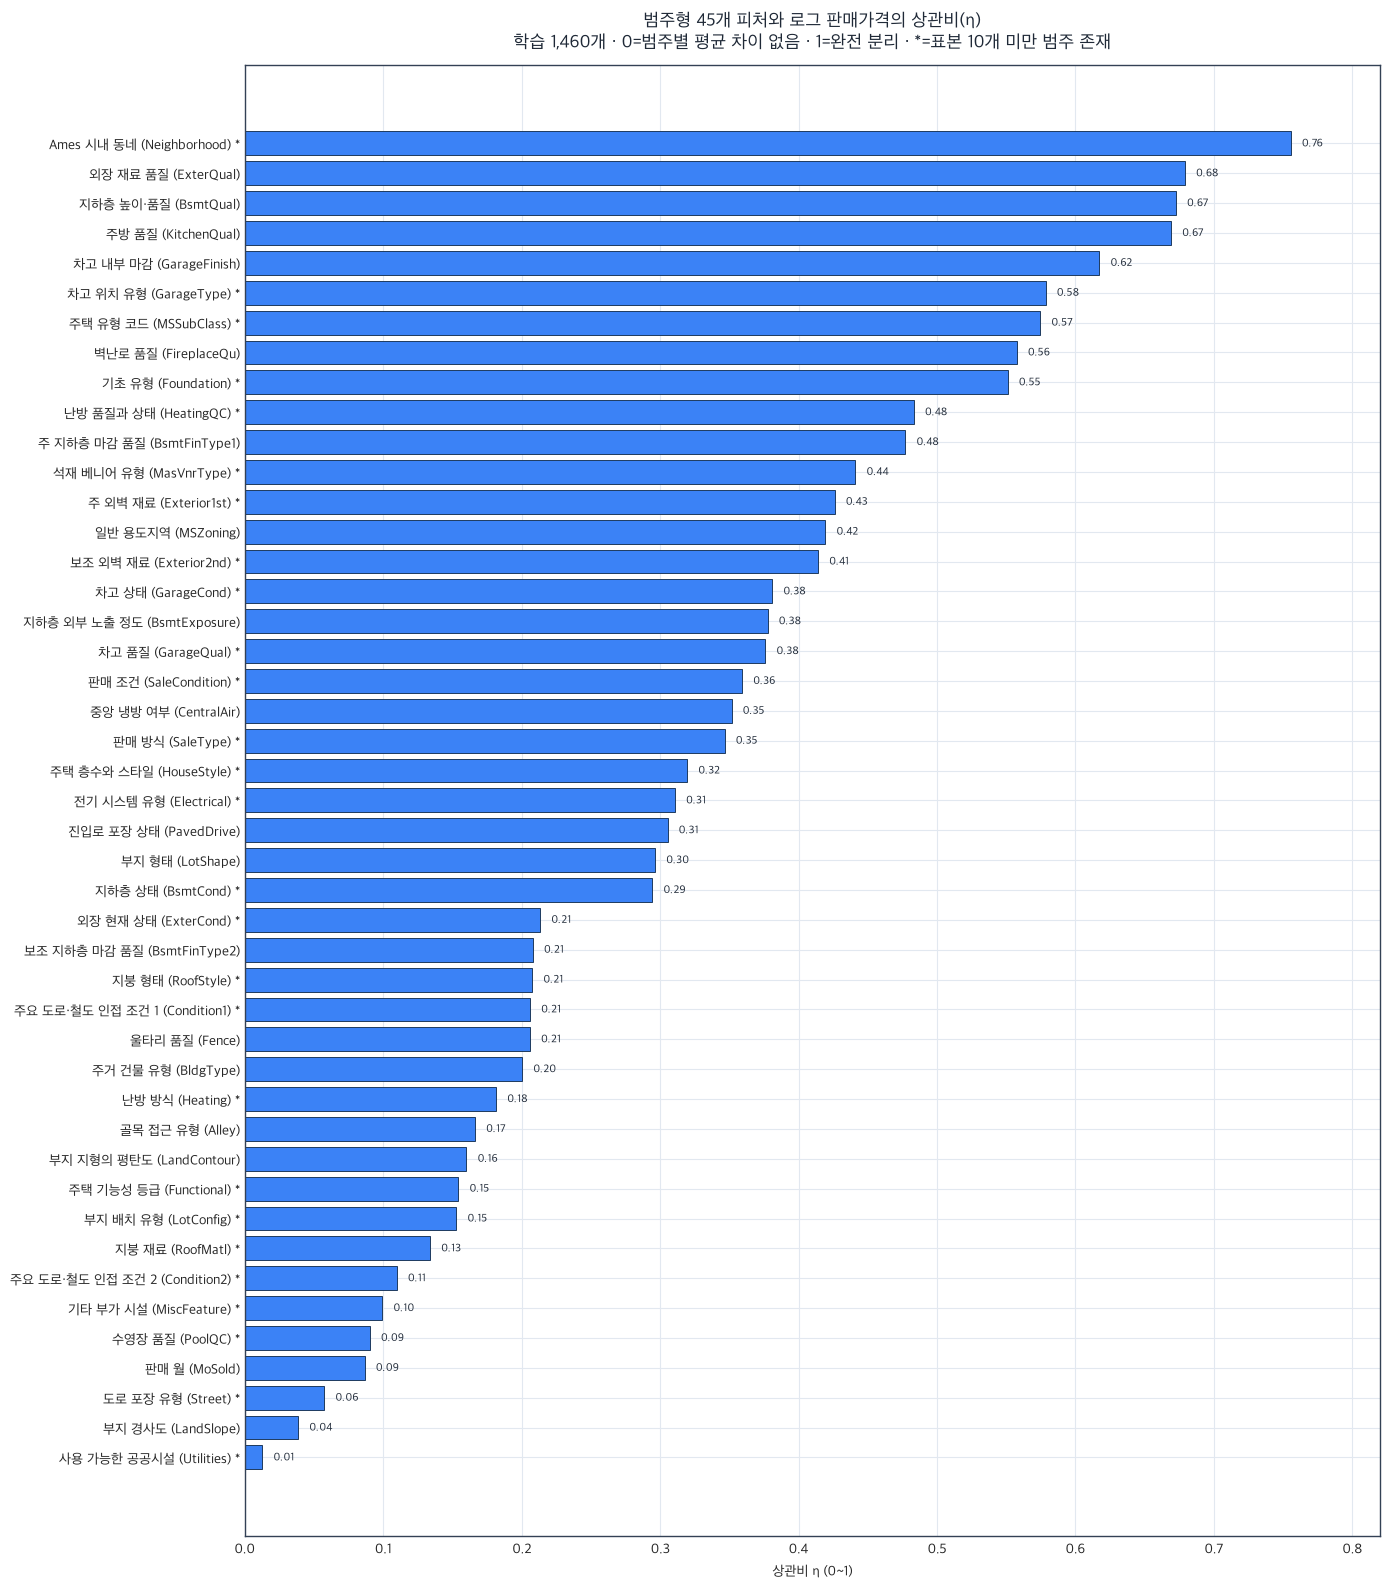

In [6]:
SEMANTIC_CATEGORICAL_NUMERIC_COLUMNS = ["MSSubClass", "MoSold"]
numeric = df.select_dtypes(include="number")
numeric_feature_columns = [
    column for column in numeric.columns
    if column not in ["Id", "SalePrice", *SEMANTIC_CATEGORICAL_NUMERIC_COLUMNS]
]
categorical_feature_columns = [
    *df.select_dtypes(exclude="number").columns.tolist(),
    *SEMANTIC_CATEGORICAL_NUMERIC_COLUMNS,
]

all_predictors = set(df.columns) - {"Id", "SalePrice"}
covered_predictors = set(numeric_feature_columns) | set(categorical_feature_columns)
assert covered_predictors == all_predictors

correlations = pd.DataFrame(index=numeric_feature_columns)
correlations["raw_target_corr"] = [df[column].corr(target) for column in numeric_feature_columns]
correlations["log_target_corr"] = [df[column].corr(log_target) for column in numeric_feature_columns]
correlations["log_spearman"] = [
    df[column].rank().corr(log_target.rank()) for column in numeric_feature_columns
]
correlations["abs_log_spearman"] = correlations["log_spearman"].abs()
correlations["valid_count"] = [df[column].notna().sum() for column in numeric_feature_columns]
correlations["missing_count"] = [df[column].isna().sum() for column in numeric_feature_columns]
correlations = correlations.sort_values("abs_log_spearman", ascending=False)

def correlation_ratio_for_eda(categories, values):
    paired = pd.DataFrame({
        "category": categories.fillna("Missing").astype(str),
        "value": values,
    }).dropna(subset=["value"])
    grand_mean = paired["value"].mean()
    grouped = paired.groupby("category", dropna=False)["value"].agg(["count", "mean"])
    between_group_sum = (
        grouped["count"] * (grouped["mean"] - grand_mean).pow(2)
    ).sum()
    total_sum = (paired["value"] - grand_mean).pow(2).sum()
    return float(np.sqrt(between_group_sum / total_sum)) if total_sum > 0 else 0.0

categorical_rows = []
for column in categorical_feature_columns:
    categories = df[column].fillna("Missing").astype(str)
    category_counts = categories.value_counts(dropna=False)
    rare_counts = category_counts[category_counts < 10]
    categorical_rows.append({
        "feature": column,
        "raw_eta": correlation_ratio_for_eda(categories, target),
        "log_eta": correlation_ratio_for_eda(categories, log_target),
        "level_count": int(category_counts.size),
        "min_level_count": int(category_counts.min()),
        "rare_level_count": int(rare_counts.size),
        "rare_row_share": rare_counts.sum() / len(df),
    })
categorical_associations = (
    pd.DataFrame(categorical_rows).set_index("feature").sort_values("log_eta", ascending=False)
)

association_coverage = pd.DataFrame([
    ["수치형", len(numeric_feature_columns), "Pearson·Spearman", "방향과 선형·단조 관계"],
    ["범주형", len(categorical_feature_columns), "상관비 η", "범주별 로그 가격 평균의 분리 정도"],
    ["합계", len(covered_predictors), "피처 79개 전체", "Id와 SalePrice만 제외"],
], columns=["피처 유형", "피처 수", "관계 지표", "해석"])
display(association_coverage)

numeric_display = correlations.copy()
numeric_display.insert(0, "한국어 의미", [FEATURE_KO.get(feature, feature) for feature in numeric_display.index])
numeric_display.index.name = "원본 변수"
with pd.option_context("display.max_rows", None):
    display(numeric_display.rename(columns={
        "raw_target_corr": "원가격 Pearson r",
        "log_target_corr": "로그가격 Pearson r",
        "log_spearman": "로그가격 Spearman ρ",
        "abs_log_spearman": "|Spearman ρ|",
        "valid_count": "유효 표본 수",
        "missing_count": "결측 수",
    }))

categorical_display = categorical_associations.copy()
categorical_display.insert(0, "한국어 의미", [FEATURE_KO.get(feature, feature) for feature in categorical_display.index])
categorical_display.index.name = "원본 변수"
with pd.option_context("display.max_rows", None):
    display(categorical_display.rename(columns={
        "raw_eta": "원가격 η",
        "log_eta": "로그가격 η",
        "level_count": "범주 수",
        "min_level_count": "최소 범주 표본 수",
        "rare_level_count": "표본 10개 미만 범주 수",
        "rare_row_share": "희소 범주 행 비율",
    }))

numeric_plot = correlations.sort_values("log_spearman")
numeric_labels = [
    f"{FEATURE_KO.get(feature, feature)} ({feature})" for feature in numeric_plot.index
]
numeric_colors = [
    "#3b82f6" if value >= 0 else "#d97706" for value in numeric_plot["log_spearman"]
]
fig, ax = plt.subplots(figsize=(14, 13))
bars = ax.barh(
    numeric_labels, numeric_plot["log_spearman"],
    color=numeric_colors, edgecolor="#334155", linewidth=0.7,
)
ax.axvline(0, color="#334155", linewidth=1.2)
ax.set_title(
    "수치형 34개 피처와 로그 판매가격의 Spearman 관계\n"
    "학습 1,460개 · 파랑=양의 관계 · 주황=음의 관계 · 결측 쌍 제외",
    pad=12,
)
ax.set_xlabel("Spearman ρ (-1~1)")
ax.set_ylabel("")
left_limit = min(-0.23, float(numeric_plot["log_spearman"].min()) - 0.08)
right_limit = max(0.88, float(numeric_plot["log_spearman"].max()) + 0.08)
ax.set_xlim(left_limit, right_limit)
for bar, value in zip(bars, numeric_plot["log_spearman"]):
    ax.text(
        value + (0.012 if value >= 0 else -0.012),
        bar.get_y() + bar.get_height() / 2,
        f"{value:.2f}",
        va="center",
        ha="left" if value >= 0 else "right",
        fontsize=8,
    )
plt.tight_layout()
plt.show()

categorical_plot = categorical_associations.sort_values("log_eta")
categorical_labels = [
    f"{FEATURE_KO.get(feature, feature)} ({feature})"
    + (" *" if categorical_plot.loc[feature, "min_level_count"] < 10 else "")
    for feature in categorical_plot.index
]
fig, ax = plt.subplots(figsize=(14, 16))
bars = ax.barh(
    categorical_labels, categorical_plot["log_eta"],
    color="#3b82f6", edgecolor="#1e3a5f", linewidth=0.7,
)
ax.set_title(
    "범주형 45개 피처와 로그 판매가격의 상관비(η)\n"
    "학습 1,460개 · 0=범주별 평균 차이 없음 · 1=완전 분리 · *=표본 10개 미만 범주 존재",
    pad=12,
)
ax.set_xlabel("상관비 η (0~1)")
ax.set_ylabel("")
ax.set_xlim(0, max(0.82, float(categorical_plot["log_eta"].max()) + 0.06))
for bar, value in zip(bars, categorical_plot["log_eta"]):
    ax.text(
        value + 0.008,
        bar.get_y() + bar.get_height() / 2,
        f"{value:.2f}",
        va="center",
        ha="left",
        fontsize=8,
    )
plt.tight_layout()
plt.show()

79개 입력 피처가 모두 포함됐습니다. 수치형에서는 `OverallQual`(ρ≈0.810), `GrLivArea`(ρ≈0.731), `GarageCars`(ρ≈0.691)가 강하고, 범주형에서는 `Neighborhood`(η≈0.756), `ExterQual`(η≈0.679), `BsmtQual`(η≈0.673), `KitchenQual`(η≈0.669)가 크게 나타납니다. 다만 `η`는 범주 수가 많거나 표본이 적은 범주가 있을 때 커질 수 있고 Pearson·Spearman과 직접 비교할 수 없습니다. 또한 단변량 관계가 약한 피처도 다른 변수와의 상호작용에서 유용할 수 있으므로, 이 그래프만으로 제거하지 않고 고정된 K-fold 교차검증의 피처 그룹 제거 실험으로 판단합니다.

### 6. 주요 변수와 판매 가격 사이에서 관찰한 패턴

,주택 수,중앙 가격,평균 가격
종합 품질 점수,,,
1,2,"50,150.000","50,150.000"
2,3,"60,000.000","51,770.333"
3,20,"86,250.000","87,473.750"
4,116,"108,000.000","108,420.655"
5,397,"133,000.000","133,523.348"
6,374,"160,000.000","161,603.035"
7,319,"200,141.000","207,716.423"
8,168,"269,750.000","274,735.536"
9,43,"345,000.000","367,513.023"


,주택 수,중앙 가격,평균 가격
동네 코드,,,
NridgHt,77,"315,000.000","316,270.623"
NoRidge,41,"301,500.000","335,295.317"
StoneBr,25,"278,000.000","310,499.000"
Timber,38,"228,475.000","242,247.447"
Somerst,86,"225,500.000","225,379.837"
Veenker,11,"218,000.000","238,772.727"
Crawfor,51,"200,624.000","210,624.725"
ClearCr,28,"200,250.000","212,565.429"
CollgCr,150,"197,200.000","197,965.773"


,원본 변수,의미,학습 데이터에서 관찰한 근거,예측에 제공하는 정보
0,OverallQual,종합 품질,"품질 5의 중앙값 $133,000 → 품질 10은 $432,390",전반적 자재·마감 수준을 요약하는 가장 강한 단일 신호
1,GrLivArea,지상 생활 면적,로그 가격 상관 r=0.701,거주 가능한 실제 크기가 커질수록 가격이 높아지는 경향
2,GarageCars,차고 수용 차량 수,로그 가격 상관 r=0.681,주차 편의성과 주택 규모·등급을 함께 반영
3,YearBuilt,건축 연도,로그 가격 상관 r=0.587,최근에 지어진 주택일수록 현대적 설비·상태 프리미엄을 보이는 경향
4,Neighborhood,동네,"표본 10개 이상 동네 중앙값 $88,000~$315,000",입지 프리미엄이 크므로 희소 범주와 타깃 누수에 주의해 인코딩


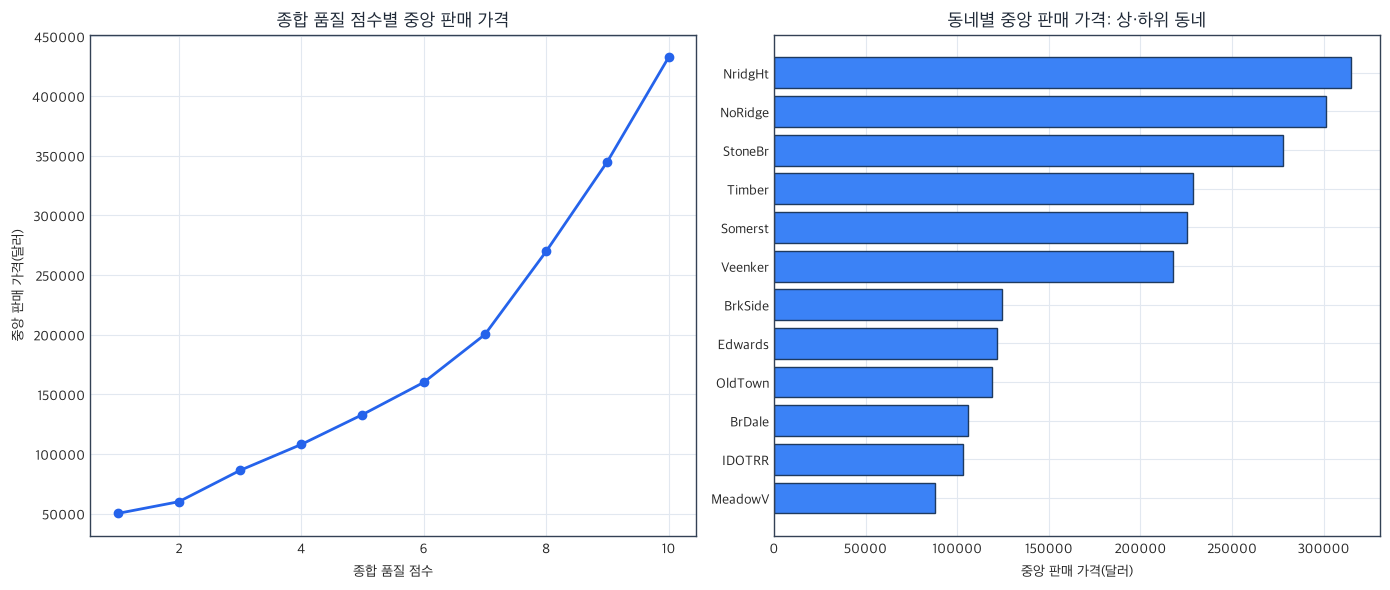

In [7]:
quality = df.groupby("OverallQual")["SalePrice"].agg(["count", "median", "mean"])
neighborhood = (
    df.groupby("Neighborhood")["SalePrice"]
    .agg(["count", "median", "mean"])
    .sort_values("median", ascending=False)
)

display(quality.rename(columns={"count": "주택 수", "median": "중앙 가격", "mean": "평균 가격"}).rename_axis("종합 품질 점수"))
display(neighborhood.rename(columns={"count": "주택 수", "median": "중앙 가격", "mean": "평균 가격"}).rename_axis("동네 코드"))

stable_neighborhoods = neighborhood[neighborhood["count"] >= 10]
extremes = pd.concat([stable_neighborhoods.head(6), stable_neighborhoods.tail(6)]).drop_duplicates()
extremes = extremes.sort_values("median")

pattern_summary = pd.DataFrame([
    [
        "OverallQual", "종합 품질",
        f"품질 5의 중앙값 ${quality.loc[5, 'median']:,.0f} → 품질 10은 ${quality.loc[10, 'median']:,.0f}",
        "전반적 자재·마감 수준을 요약하는 가장 강한 단일 신호",
    ],
    [
        "GrLivArea", "지상 생활 면적",
        f"로그 가격 상관 r={correlations.loc['GrLivArea', 'log_target_corr']:.3f}",
        "거주 가능한 실제 크기가 커질수록 가격이 높아지는 경향",
    ],
    [
        "GarageCars", "차고 수용 차량 수",
        f"로그 가격 상관 r={correlations.loc['GarageCars', 'log_target_corr']:.3f}",
        "주차 편의성과 주택 규모·등급을 함께 반영",
    ],
    [
        "YearBuilt", "건축 연도",
        f"로그 가격 상관 r={correlations.loc['YearBuilt', 'log_target_corr']:.3f}",
        "최근에 지어진 주택일수록 현대적 설비·상태 프리미엄을 보이는 경향",
    ],
    [
        "Neighborhood", "동네",
        f"표본 10개 이상 동네 중앙값 ${stable_neighborhoods.iloc[-1]['median']:,.0f}~${stable_neighborhoods.iloc[0]['median']:,.0f}",
        "입지 프리미엄이 크므로 희소 범주와 타깃 누수에 주의해 인코딩",
    ],
], columns=["원본 변수", "의미", "학습 데이터에서 관찰한 근거", "예측에 제공하는 정보"])
display(pattern_summary)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
axes[0].plot(quality.index, quality["median"], marker="o", color="#2563eb", linewidth=2)
axes[0].set_title("종합 품질 점수별 중앙 판매 가격")
axes[0].set_xlabel("종합 품질 점수")
axes[0].set_ylabel("중앙 판매 가격(달러)")

axes[1].barh(extremes.index, extremes["median"], color="#3b82f6", edgecolor="#1e3a5f")
axes[1].set_title("동네별 중앙 판매 가격: 상·하위 동네")
axes[1].set_xlabel("중앙 판매 가격(달러)")
axes[1].set_ylabel("")

plt.tight_layout()
plt.show()

`OverallQual` 5→10에서 중앙 가격은 $133k→$432k로 뚜렷하게 증가합니다. 표본 10개 이상 동네 중 `NridgHt` 중앙값은 $315k, `MeadowV`는 $88k로 약 3.6배 차이가 나므로 `Neighborhood`는 원-핫 인코딩 또는 타깃 누수 없는 범주형 처리의 핵심 후보입니다.

### 7. 변수 간 상관·연관성과 중복 신호 점검하기

,0의 비율
수영장 면적,0.995
3계절용 현관 면적,0.984
저품질 마감 면적,0.982
기타 부가 시설 가치,0.964
지하층 반욕실 수,0.944
스크린 현관 면적,0.921
보조 지하층 마감 면적,0.886
폐쇄형 현관 면적,0.858
지상 반욕실 수,0.625
석재 베니어 면적(제곱피트),0.590


,왜도
기타 부가 시설 가치,24.477
수영장 면적,14.828
부지 면적(제곱피트),12.208
3계절용 현관 면적,10.304
저품질 마감 면적,9.011
지상 주방 수,4.488
보조 지하층 마감 면적,4.255
스크린 현관 면적,4.122
지하층 반욕실 수,4.103
폐쇄형 현관 면적,3.090


,변수 1,변수 1 의미,변수 2,변수 2 의미,Pearson r,Spearman ρ,유효 표본 수,|Pearson r|
0,GarageCars,차고 수용 차량 수,GarageArea,차고 면적(제곱피트),0.882,0.853,1460,0.882
1,YearBuilt,최초 건축 연도,GarageYrBlt,차고 건축 연도,0.826,0.891,1379,0.826
2,GrLivArea,지상 생활 면적(제곱피트),TotRmsAbvGrd,지상 전체 방 수,0.825,0.828,1460,0.825
3,TotalBsmtSF,전체 지하층 면적,1stFlrSF,1층 면적(제곱피트),0.820,0.829,1460,0.820
4,2ndFlrSF,2층 면적(제곱피트),GrLivArea,지상 생활 면적(제곱피트),0.688,0.643,1460,0.688
5,BedroomAbvGr,지상 침실 수,TotRmsAbvGrd,지상 전체 방 수,0.677,0.668,1460,0.677
6,BsmtFinSF1,주 지하층 마감 면적,BsmtFullBath,지하층 전체 욕실 수,0.649,0.674,1460,0.649
7,YearRemodAdd,리모델링 연도,GarageYrBlt,차고 건축 연도,0.642,0.722,1379,0.642
8,GrLivArea,지상 생활 면적(제곱피트),FullBath,지상 전체 욕실 수,0.630,0.658,1460,0.630
9,2ndFlrSF,2층 면적(제곱피트),TotRmsAbvGrd,지상 전체 방 수,0.616,0.587,1460,0.616


,변수 1,변수 1 의미,변수 2,변수 2 의미,편향 보정 Cramér's V,기대빈도 5 미만 셀 비율,관측된 셀 수,유효 표본 수
0,BldgType,주거 건물 유형,MSSubClass,주택 유형 코드,0.891,0.653,20,1460
1,HouseStyle,주택 층수와 스타일,MSSubClass,주택 유형 코드,0.848,0.675,36,1460
2,Exterior1st,주 외벽 재료,Exterior2nd,보조 외벽 재료,0.759,0.800,67,1460
3,GarageQual,차고 품질,GarageCond,차고 상태,0.704,0.778,12,1460
4,GarageType,차고 위치 유형,GarageFinish,차고 내부 마감,0.685,0.429,17,1460
5,MSZoning,일반 용도지역,Neighborhood,Ames 시내 동네,0.641,0.656,42,1460
6,GarageFinish,차고 내부 마감,GarageQual,차고 품질,0.589,0.542,12,1460
7,GarageFinish,차고 내부 마감,GarageCond,차고 상태,0.586,0.583,12,1460
8,BsmtQual,지하층 높이·품질,BsmtFinType1,주 지하층 마감 품질,0.577,0.257,23,1460
9,ExterQual,외장 재료 품질,KitchenQual,주방 품질,0.546,0.250,12,1460


,범주형 변수,범주형 의미,수치형 변수,수치형 의미,상관비 η,유효 표본 수,범주 수,최소 범주 표본 수,희소 범주 행 비율
0,PoolQC,수영장 품질,PoolArea,수영장 면적,0.991,1460,4,2,0.005
1,MiscFeature,기타 부가 시설,MiscVal,기타 부가 시설 가치,0.936,1460,5,1,0.003
2,HouseStyle,주택 층수와 스타일,2ndFlrSF,2층 면적(제곱피트),0.917,1460,8,8,0.005
3,FireplaceQu,벽난로 품질,Fireplaces,벽난로 수,0.901,1460,6,20,0.000
4,MSSubClass,주택 유형 코드,2ndFlrSF,2층 면적(제곱피트),0.900,1460,15,4,0.003
5,Neighborhood,Ames 시내 동네,YearBuilt,최초 건축 연도,0.884,1460,25,2,0.008
6,BsmtFinType2,보조 지하층 마감 품질,BsmtFinSF2,보조 지하층 마감 면적,0.839,1460,7,14,0.000
7,MSSubClass,주택 유형 코드,YearBuilt,최초 건축 연도,0.815,1460,15,4,0.003
8,MSSubClass,주택 유형 코드,KitchenAbvGr,지상 주방 수,0.784,1460,15,4,0.003
9,Neighborhood,Ames 시내 동네,GarageYrBlt,차고 건축 연도,0.781,1379,25,2,0.008


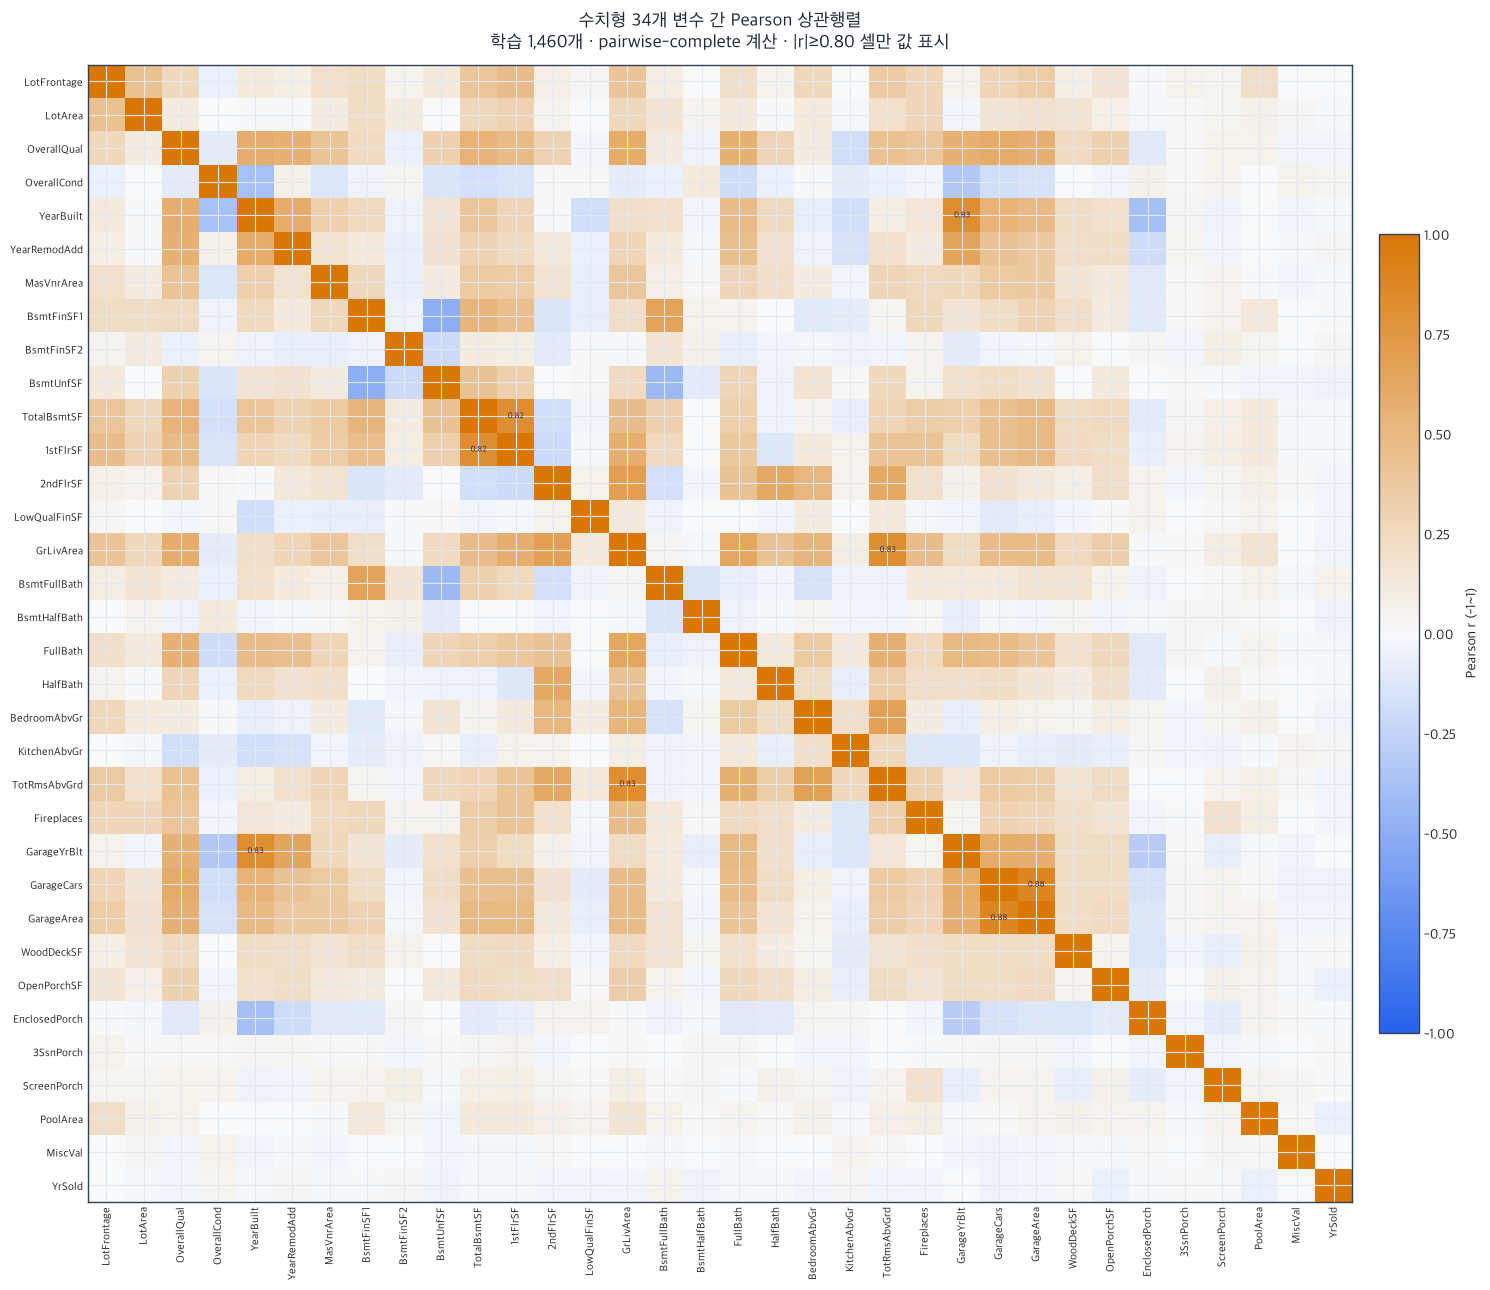

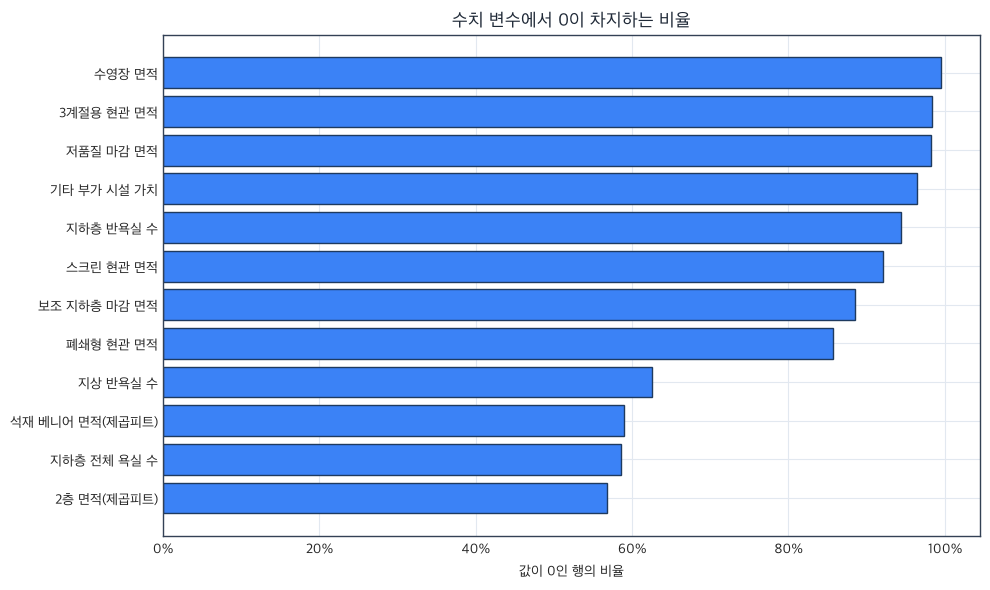

In [8]:
feature_numeric = df[numeric_feature_columns]
zero_share = feature_numeric.eq(0).mean().sort_values(ascending=False)
numeric_skew = feature_numeric.skew().sort_values(ascending=False)

numeric_pearson = feature_numeric.corr(method="pearson")
numeric_spearman = feature_numeric.corr(method="spearman")
pairwise_valid_counts = feature_numeric.notna().astype(int).T.dot(
    feature_numeric.notna().astype(int)
)

numeric_pair_rows = []
for left_index, feature_1 in enumerate(numeric_feature_columns):
    for feature_2 in numeric_feature_columns[left_index + 1:]:
        numeric_pair_rows.append({
            "변수 1": feature_1,
            "변수 1 의미": FEATURE_KO.get(feature_1, feature_1),
            "변수 2": feature_2,
            "변수 2 의미": FEATURE_KO.get(feature_2, feature_2),
            "Pearson r": numeric_pearson.loc[feature_1, feature_2],
            "Spearman ρ": numeric_spearman.loc[feature_1, feature_2],
            "유효 표본 수": int(pairwise_valid_counts.loc[feature_1, feature_2]),
        })
numeric_pairs = pd.DataFrame(numeric_pair_rows)
numeric_pairs["|Pearson r|"] = numeric_pairs["Pearson r"].abs()
numeric_pairs = numeric_pairs.sort_values("|Pearson r|", ascending=False).reset_index(drop=True)

def bias_corrected_cramers_v_for_eda(left, right):
    contingency = pd.crosstab(
        left.fillna("Missing").astype(str),
        right.fillna("Missing").astype(str),
        dropna=False,
    )
    observed = contingency.to_numpy(dtype=float)
    sample_count = observed.sum()
    expected = (
        observed.sum(axis=1, keepdims=True)
        @ observed.sum(axis=0, keepdims=True)
        / sample_count
    )
    chi_squared = np.divide(
        (observed - expected) ** 2,
        expected,
        out=np.zeros_like(expected),
        where=expected > 0,
    ).sum()
    phi_squared = chi_squared / sample_count
    row_count, column_count = observed.shape
    corrected_phi_squared = max(
        0.0,
        phi_squared - ((column_count - 1) * (row_count - 1)) / (sample_count - 1),
    )
    corrected_rows = row_count - ((row_count - 1) ** 2) / (sample_count - 1)
    corrected_columns = column_count - ((column_count - 1) ** 2) / (sample_count - 1)
    denominator = min(corrected_rows - 1, corrected_columns - 1)
    value = np.sqrt(corrected_phi_squared / denominator) if denominator > 0 else 0.0
    return float(value), float((expected < 5).mean()), int(np.count_nonzero(observed))

categorical_pair_rows = []
for left_index, feature_1 in enumerate(categorical_feature_columns):
    for feature_2 in categorical_feature_columns[left_index + 1:]:
        cramers_v, sparse_expected_share, nonzero_cells = bias_corrected_cramers_v_for_eda(
            df[feature_1], df[feature_2]
        )
        categorical_pair_rows.append({
            "변수 1": feature_1,
            "변수 1 의미": FEATURE_KO.get(feature_1, feature_1),
            "변수 2": feature_2,
            "변수 2 의미": FEATURE_KO.get(feature_2, feature_2),
            "편향 보정 Cramér's V": cramers_v,
            "기대빈도 5 미만 셀 비율": sparse_expected_share,
            "관측된 셀 수": nonzero_cells,
            "유효 표본 수": len(df),
        })
categorical_pairs = pd.DataFrame(categorical_pair_rows).sort_values(
    "편향 보정 Cramér's V", ascending=False
).reset_index(drop=True)

mixed_pair_rows = []
for categorical_feature in categorical_feature_columns:
    categories = df[categorical_feature].fillna("Missing").astype(str)
    for numeric_feature in numeric_feature_columns:
        paired = pd.DataFrame({
            "category": categories,
            "value": df[numeric_feature],
        }).dropna(subset=["value"])
        level_counts = paired["category"].value_counts(dropna=False)
        rare_level_counts = level_counts[level_counts < 10]
        mixed_pair_rows.append({
            "범주형 변수": categorical_feature,
            "범주형 의미": FEATURE_KO.get(categorical_feature, categorical_feature),
            "수치형 변수": numeric_feature,
            "수치형 의미": FEATURE_KO.get(numeric_feature, numeric_feature),
            "상관비 η": correlation_ratio_for_eda(paired["category"], paired["value"]),
            "유효 표본 수": len(paired),
            "범주 수": int(level_counts.size),
            "최소 범주 표본 수": int(level_counts.min()),
            "희소 범주 행 비율": rare_level_counts.sum() / len(paired),
        })
mixed_pairs = pd.DataFrame(mixed_pair_rows).sort_values(
    "상관비 η", ascending=False
).reset_index(drop=True)

zero_display = zero_share.head(15).to_frame("0의 비율")
zero_display.index = [FEATURE_KO.get(feature, feature) for feature in zero_display.index]
skew_display = numeric_skew.head(15).to_frame("왜도")
skew_display.index = [FEATURE_KO.get(feature, feature) for feature in skew_display.index]
display(zero_display)
display(skew_display)
display(numeric_pairs.head(15))
display(categorical_pairs.head(15))
display(mixed_pairs.head(15))

from matplotlib.colors import LinearSegmentedColormap

blue_orange = LinearSegmentedColormap.from_list(
    "blue_orange", ["#2563eb", "#f8fafc", "#d97706"]
)
fig, ax = plt.subplots(figsize=(15, 13))
image = ax.imshow(numeric_pearson, cmap=blue_orange, vmin=-1, vmax=1, aspect="auto")
ax.set_xticks(range(len(numeric_feature_columns)))
ax.set_xticklabels(numeric_feature_columns, rotation=90, fontsize=8)
ax.set_yticks(range(len(numeric_feature_columns)))
ax.set_yticklabels(numeric_feature_columns, fontsize=8)
ax.set_title(
    "수치형 34개 변수 간 Pearson 상관행렬\n"
    "학습 1,460개 · pairwise-complete 계산 · |r|≥0.80 셀만 값 표시",
    pad=12,
)
for row_index in range(len(numeric_feature_columns)):
    for column_index in range(len(numeric_feature_columns)):
        value = numeric_pearson.iloc[row_index, column_index]
        if row_index != column_index and abs(value) >= 0.80:
            ax.text(column_index, row_index, f"{value:.2f}", ha="center", va="center", fontsize=6)
colorbar = fig.colorbar(image, ax=ax, fraction=0.03, pad=0.02)
colorbar.set_label("Pearson r (-1~1)")
plt.tight_layout()
plt.show()

plot_data = zero_share.head(12).sort_values()
plot_data.index = [FEATURE_KO.get(feature, feature) for feature in plot_data.index]
fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(plot_data.index, plot_data, color="#3b82f6", edgecolor="#1e3a5f")
ax.set_title("수치 변수에서 0이 차지하는 비율")
ax.set_xlabel("값이 0인 행의 비율")
ax.set_ylabel("")
ax.xaxis.set_major_formatter(lambda value, _: f"{value:.0%}")
plt.tight_layout()
plt.show()

수치형 561쌍 중 |Pearson r|≥0.80인 쌍은 4개입니다. `GarageCars`–`GarageArea`(r=0.882), `YearBuilt`–`GarageYrBlt`(r≈0.826), `GrLivArea`–`TotRmsAbvGrd`(r≈0.825), `TotalBsmtSF`–`1stFlrSF`(r≈0.820)는 같은 규모·연식 개념을 겹쳐 측정하므로 규제 선형 모델의 공선성과 모델 중요도 분산을 점검해야 합니다.

범주형에서는 `BldgType`–`MSSubClass`(편향 보정 V≈0.891), 혼합형에서는 `PoolQC`–`PoolArea`(η≈0.991)가 가장 컸습니다. 전자는 주택 유형 코드가 건물 형태를 함께 정의하는 관계이고, 후자는 수영장이 없으면 면적도 0인 구조적 관계입니다. 따라서 큰 값이 독립적인 예측 정보를 뜻하지는 않습니다. 범주표의 기대빈도 5 미만 셀 비율과 혼합표의 최소 범주 표본 수를 함께 보고, 최종 제거·통합 여부는 고정 fold ablation으로 결정합니다.

`PoolArea`, `3SsnPorch`, `LowQualFinSF`, `MiscVal`은 96% 이상이 0입니다. 연속형 그대로만 쓰기보다 `HasPool`, `Has3SsnPorch` 같은 존재 여부 플래그와 크기를 분리하는 가설을 후속 CV에서 검증합니다.

### 8. 이상치 후보와 생활 면적이 매우 큰 주택 점검하기

,변수,IQR 하단 경계,IQR 상단 경계,후보 수,후보 비율
0,판매 가격(달러),"3,937.500","340,037.500",61,0.042
1,지상 생활 면적(제곱피트),158.625,"2,747.625",31,0.021
2,부지 면적(제곱피트),"1,481.500","17,673.500",69,0.047
3,전체 지하층 면적,42.000,"2,052.000",61,0.042
4,차고 면적(제곱피트),-27.750,938.250,21,0.014
5,최초 건축 연도,"1,885.000","2,069.000",7,0.005


,주택 ID,지상 생활 면적,종합 품질,동네 코드,판매 가격,생활 면적당 가격
691,692,4316,10,NoRidge,755000,174.930
1182,1183,4476,10,NoRidge,745000,166.443
523,524,4676,10,Edwards,184750,39.510
1298,1299,5642,10,Edwards,160000,28.359


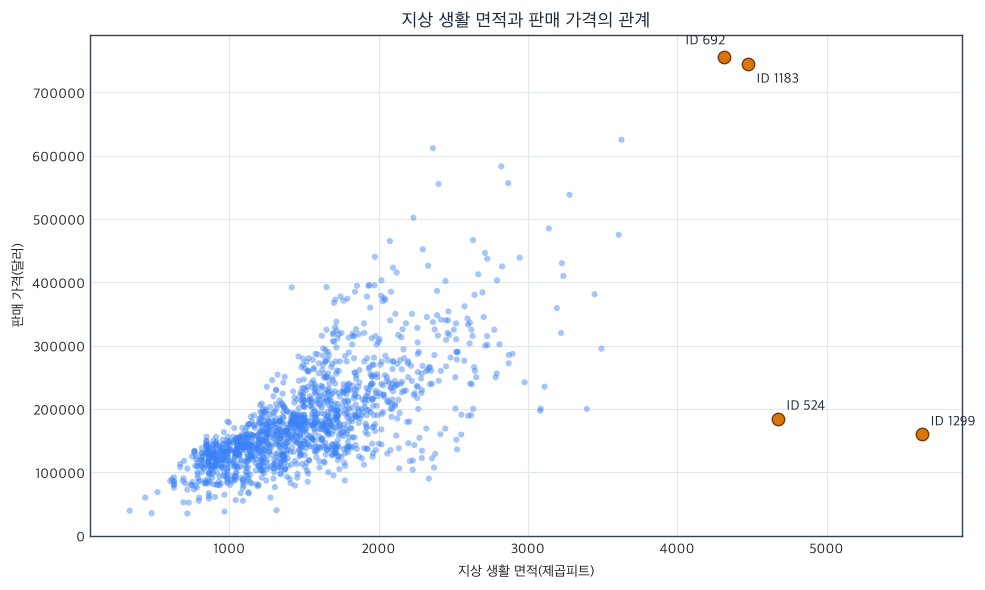

In [9]:
iqr_columns = ["SalePrice", "GrLivArea", "LotArea", "TotalBsmtSF", "GarageArea", "YearBuilt"]
iqr_rows = []
for column in iqr_columns:
    q1 = df[column].quantile(0.25)
    q3 = df[column].quantile(0.75)
    lower = q1 - 1.5 * (q3 - q1)
    upper = q3 + 1.5 * (q3 - q1)
    is_iqr_candidate = (df[column] < lower) | (df[column] > upper)
    iqr_rows.append({
        "변수": FEATURE_KO.get(column, column),
        "IQR 하단 경계": lower,
        "IQR 상단 경계": upper,
        "후보 수": int(is_iqr_candidate.sum()),
        "후보 비율": is_iqr_candidate.mean(),
    })
display(pd.DataFrame(iqr_rows))

large_homes = df.loc[
    df["GrLivArea"] > 4000,
    ["Id", "GrLivArea", "OverallQual", "Neighborhood", "SalePrice"],
].copy()
large_homes["price_per_living_sf"] = large_homes["SalePrice"] / large_homes["GrLivArea"]
display(large_homes.sort_values("GrLivArea").rename(columns={
    "Id": "주택 ID", "GrLivArea": "지상 생활 면적", "OverallQual": "종합 품질",
    "Neighborhood": "동네 코드", "SalePrice": "판매 가격",
    "price_per_living_sf": "생활 면적당 가격",
}))

fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(df["GrLivArea"], df["SalePrice"], s=20, alpha=0.45, color="#3b82f6", edgecolors="none")
highlight = large_homes
ax.scatter(highlight["GrLivArea"], highlight["SalePrice"], s=80, color="#d97706", edgecolors="#78350f")
label_offsets = {524: (6, 6), 692: (-28, 9), 1183: (6, -14), 1299: (6, 6)}
for _, row in highlight.iterrows():
    row_id = int(row["Id"])
    ax.annotate(
        f"ID {row_id}",
        (row["GrLivArea"], row["SalePrice"]),
        xytext=label_offsets.get(row_id, (6, 6)),
        textcoords="offset points",
    )
ax.set_title("지상 생활 면적과 판매 가격의 관계")
ax.set_xlabel("지상 생활 면적(제곱피트)")
ax.set_ylabel("판매 가격(달러)")
plt.tight_layout()
plt.show()

IQR 기준은 특이한 값을 찾는 **후보 표시 규칙**이지 오류 판정이 아닙니다. 넓은 부지·고가 주택은 실제 시장에 존재하므로 일괄 삭제하면 고가 주택 예측이 편향될 수 있습니다. 4,000 sq ft 초과 4개 중 `Id=692`, `Id=1183`은 고급 대형 주택 가격대와 일치하지만 `Id=524`, `Id=1299`는 면적 대비 가격이 매우 낮습니다. 전체 모델과 해당 두 행 제외 모델을 같은 fold로 비교해 로그 RMSE의 평균과 변동성이 실제로 개선되는 경우에만 제외를 고려합니다.

### 9. 간단한 파생 변수 효과 확인하기

In [10]:
engineered = pd.DataFrame(index=df.index)
engineered["TotalSF"] = df["TotalBsmtSF"] + df["1stFlrSF"] + df["2ndFlrSF"]
engineered["TotalBath"] = df["FullBath"] + 0.5 * df["HalfBath"] + df["BsmtFullBath"] + 0.5 * df["BsmtHalfBath"]
engineered["HouseAgeAtSale"] = df["YrSold"] - df["YearBuilt"]
engineered["RemodelAgeAtSale"] = df["YrSold"] - df["YearRemodAdd"]
engineered["TotalPorchSF"] = df[["WoodDeckSF", "OpenPorchSF", "EnclosedPorch", "3SsnPorch", "ScreenPorch"]].sum(axis=1)

engineered_summary = pd.DataFrame({
    "raw_target_corr": engineered.corrwith(target),
    "log_target_corr": engineered.corrwith(log_target),
}).sort_values("log_target_corr", key=abs, ascending=False)
engineered_summary.index = [FEATURE_KO.get(feature, feature) for feature in engineered_summary.index]
display(engineered_summary.rename(columns={
    "raw_target_corr": "원가격 상관계수",
    "log_target_corr": "로그 가격 상관계수",
}))
print("판매 당시 주택 연령이 음수인 행:", int((engineered["HouseAgeAtSale"] < 0).sum()))
print("판매 당시 리모델링 경과 연수가 음수인 행:", int((engineered["RemodelAgeAtSale"] < 0).sum()))

,원가격 상관계수,로그 가격 상관계수
TotalSF,0.782,0.777
TotalBath,0.632,0.673
HouseAgeAtSale,-0.523,-0.587
RemodelAgeAtSale,-0.509,-0.568
TotalPorchSF,0.391,0.398


판매 당시 주택 연령이 음수인 행: 0
판매 당시 리모델링 경과 연수가 음수인 행: 1


`TotalSF`는 로그 타깃과 r≈0.777로 강하며, 총 욕실 수와 판매 당시 주택/리모델링 연령도 유용합니다. `RemodelAgeAtSale < 0`인 1개 행은 데이터 오류나 특수 거래일 수 있으므로 모델링 전에 확인하거나 0으로 클리핑하는 민감도 검사가 필요합니다.

## 결론 및 학습 데이터 모델링 방향

1. `SalePrice`는 `log1p`로 변환하고, 검증 점수도 로그 공간 RMSE로 계산합니다.
2. 범주형 구조적 결측은 `None`이라는 정보로 보존하고, `LotFrontage`·`MasVnrArea`·`Electrical` 등 실제 미상 값은 학습 fold 내부에서 대치합니다.
3. 79개 입력 피처를 모두 초기 후보로 유지하되 `OverallQual`, `GrLivArea`, 차고, 연식, 품질 범주, 동네를 강한 단변량 신호로 우선 점검합니다.
4. 높은 변수 간 연관성은 중복 신호 후보로만 사용하고, 대표 변수 선택·합성 feature·원본 동시 유지 전략을 동일한 fold에서 비교합니다.
5. `Id=524`, `Id=1299` 제거 여부는 동일한 교차검증 분할에서 민감도 검사로 결정합니다.
6. 관계가 약해 보이는 피처도 그래프만으로 삭제하지 않고, 동일한 K-fold에서 피처 그룹 제거 전후의 로그 RMSE 평균·표준편차를 비교합니다.